# EDA 04 — Análisis exploratorio univariado

**Objetivo:** estudiar una variable a la vez mediante distribuciones, frecuencias, valores faltantes y gráficos reproducibles.

Esta etapa tiene dos ámbitos deliberadamente separados:

1. Las **covariables y sus faltantes** se describen en el dominio completo de educación superior completada (n=39 551), usando `fexp` para obtener composiciones ponderadas.
2. La **variable objetivo** se examina solamente en entrenamiento (n=31 502), como diagnóstico para desarrollar modelos. La prueba reservada no se lee.

Los porcentajes ponderados son descriptivos. Los intervalos de confianza y contrastes que incorporan estratos y UPM pertenecen a una etapa inferencial posterior.

In [1]:
# ETAPA 4 / ARCHIVO: cuaderno 04 / BLOQUE 1: localizar resultados verificados.
from pathlib import Path  # Representa carpetas y archivos.
import json  # Lee resúmenes estructurados.
import pandas as pd  # Trabaja con tablas.
from IPython.display import SVG, display  # Presenta tablas y figuras editables.
RAIZ = Path.cwd() if (Path.cwd() / 'reports/eda04_univariado').exists() else Path.cwd().parent  # Admite iniciar en proyecto o notebooks.
REPORTES = RAIZ / 'reports/eda04_univariado'  # Localiza las tablas.
FIGURAS = RAIZ / 'reports/figures/eda04_univariado'  # Localiza los gráficos.
resumen = json.loads((REPORTES / '00_resumen_eda04.json').read_text(encoding='utf-8'))  # Recupera resultados centrales.
verificacion = json.loads((REPORTES / '10_verificacion_eda04.json').read_text(encoding='utf-8'))  # Recupera controles.
assert verificacion['estado'] == 'verificado'  # Exige una entrega validada.
assert verificacion['prueba_reservada_leida'] is False  # Confirma que la prueba sigue cerrada.
display(pd.Series(resumen, name='valor').to_frame())  # Presenta el alcance sin registros individuales.

,valor
estado,completado
filas_dominio,39551
filas_entrenamiento_objetivo,31502
filas_ocupados,36906
ingresos_observados,35080
variables_categoricas,"[p02, p06, p07, p10a, p15, prov, area, mes]"
variables_numericas,[edad_limite_inferior]
maximo_faltante_covariables_porcentaje,0.0
edad_media_ponderada,39.062488
edad_mediana_ponderada,37.0


## 1. Valores faltantes

Un faltante es la ausencia real de un dato, no una categoría sustantiva. Las diez covariables previstas y `fexp` están completas en el dominio. Esta comprobación no se extiende automáticamente a las restantes variables de la encuesta. En ingresos, los vacíos y códigos especiales tienen significados diferentes y se estudian por separado.

,variable,n_total,n_faltante,porcentaje_faltante,porcentaje_ponderado_faltante
0,edad_limite_inferior,39551,0,0.0,0.0
1,p02,39551,0,0.0,0.0
2,p06,39551,0,0.0,0.0
3,p07,39551,0,0.0,0.0
4,p10a,39551,0,0.0,0.0
5,p15,39551,0,0.0,0.0
6,prov,39551,0,0.0,0.0
7,area,39551,0,0.0,0.0
8,mes,39551,0,0.0,0.0
9,fexp,39551,0,0.0,0.0


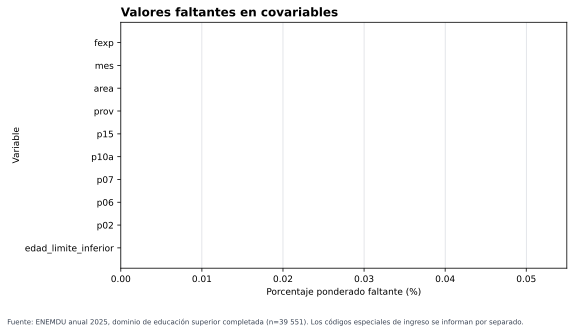

In [2]:
# BLOQUE 2: revisar ausencia de datos en las covariables.
faltantes = pd.read_csv(REPORTES / '01_faltantes_covariables_dominio.csv')  # Lee conteos y porcentajes.
display(faltantes[['variable', 'n_total', 'n_faltante', 'porcentaje_faltante', 'porcentaje_ponderado_faltante']])  # Muestra denominadores y resultados.
assert faltantes['n_faltante'].eq(0).all()  # Comprueba el hallazgo de completitud.
display(SVG(filename=str(FIGURAS / '06_faltantes_covariables.svg')))  # Presenta la versión vectorial del gráfico.

## 2. Variable numérica: edad

La mediana ponderada es 37 años y la media ponderada, 39,06. La diferencia es compatible con una cola hacia edades mayores. El valor 98 significa **98 años o más** y se presenta como categoría abierta; no debe interpretarse como edad exacta.

,medida,sin_ponderar,ponderado
0,n_valido,39551.000000,1.382774e+06
1,n_faltante,0.000000,0.000000e+00
2,media,40.280069,3.906249e+01
3,desviacion_estandar,12.367312,1.169343e+01
4,cuantil_0.00,18.000000,1.800000e+01
5,cuantil_0.01,22.000000,2.200000e+01
6,cuantil_0.05,24.000000,2.400000e+01
7,cuantil_0.25,30.000000,3.000000e+01
8,cuantil_0.50,38.000000,3.700000e+01
9,cuantil_0.75,49.000000,4.600000e+01


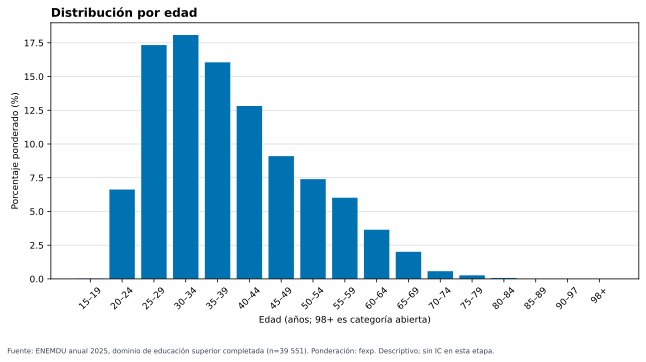

In [3]:
# BLOQUE 3: examinar medidas y distribución de edad.
edad = pd.read_csv(REPORTES / '03_resumen_edad_dominio.csv')  # Lee medidas con y sin ponderación.
display(edad)  # Permite comparar ambos enfoques.
display(SVG(filename=str(FIGURAS / '01_distribucion_edad.svg')))  # Presenta la distribución ponderada.

## 3. Variables categóricas

Las frecuencias ponderadas describen la composición del dominio según el factor anual. Destacan 54,9 % de mujeres, 85,8 % de residentes urbanos y 64,6 % con nivel superior universitario reportado. Estas cifras aún no incluyen intervalos de confianza del diseño complejo.

,variable,codigo,etiqueta,n,porcentaje,porcentaje_ponderado
0,p02,1,Hombre,18198,46.011479,45.092031
1,p02,2,Mujer,21353,53.988521,54.907969
10,p10a,10,Post-grado,7262,18.361103,15.752461
11,p10a,8,Superior no universitario,6425,16.244848,19.673125
12,p10a,9,Superior Universitario,25864,65.394048,64.574414
13,p15,1,Indígena,1037,2.621931,3.479619
14,p15,2,Afroecuatoriano,478,1.208566,0.988975
15,p15,3,Negro,261,0.659907,0.552211
16,p15,4,Mulato,178,0.450052,0.416909
17,p15,5,Montuvio,219,0.553715,1.392516


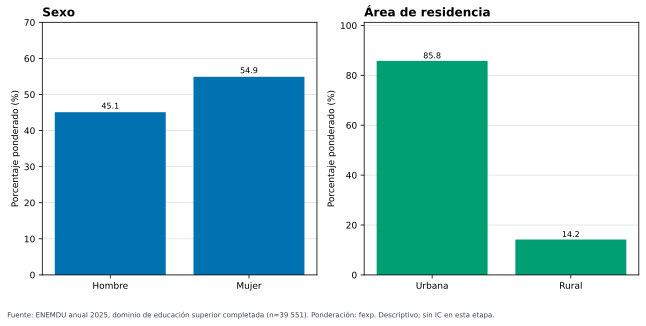

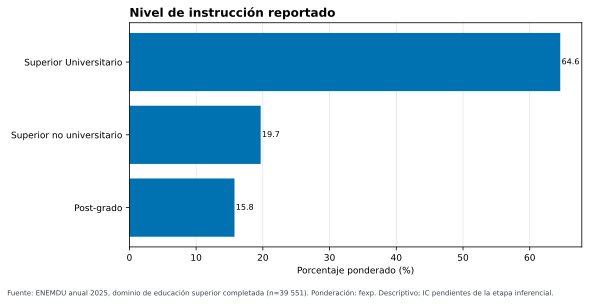

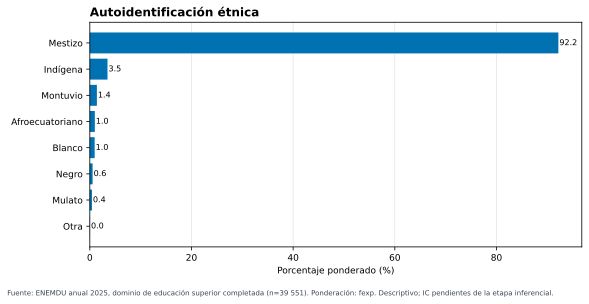

In [4]:
# BLOQUE 4: consultar frecuencias categóricas completas.
frecuencias = pd.read_csv(REPORTES / '02_frecuencias_categoricas_dominio.csv', dtype={'codigo': 'string'})  # Conserva códigos como texto.
seleccion = frecuencias.loc[frecuencias['variable'].isin(['p02', 'area', 'p10a', 'p15'])]  # Selecciona cuatro variables para lectura guiada.
display(seleccion[['variable', 'codigo', 'etiqueta', 'n', 'porcentaje', 'porcentaje_ponderado']])  # Contrasta composición muestral y ponderada.
display(SVG(filename=str(FIGURAS / '04_composicion_sexo_area.svg')))  # Presenta sexo y área.
display(SVG(filename=str(FIGURAS / '02_nivel_instruccion.svg')))  # Presenta nivel reportado.
display(SVG(filename=str(FIGURAS / '03_autoidentificacion_etnica.svg')))  # Presenta autoidentificación.

## 4. Variable objetivo solo en entrenamiento

El 69,5 % ponderado de entrenamiento está etiquetado como empleo adecuado. Es un diagnóstico del conjunto de desarrollo, **no una estimación nacional** y tampoco un resultado final. Sirve para anticipar que la exactitud aislada será insuficiente: deberán informarse sensibilidad, especificidad, ROC-AUC, PR-AUC y calibración. La prueba continúa sin inspeccionarse.

In [5]:
# BLOQUE 5: revisar la etiqueta disponible para desarrollar modelos.
objetivo = pd.read_csv(REPORTES / '05_frecuencia_objetivo_entrenamiento.csv', dtype={'codigo': 'string'})  # Lee exclusivamente el resumen de entrenamiento.
display(objetivo[['etiqueta', 'n', 'porcentaje', 'porcentaje_ponderado']])  # Presenta el equilibrio de clases.
assert objetivo['n'].sum() == resumen['filas_entrenamiento_objetivo']  # Verifica el denominador.
assert resumen['prueba_reservada_leida'] is False  # Reafirma la reserva metodológica.

,etiqueta,n,porcentaje,porcentaje_ponderado
0,No adecuado,9362,29.718748,30.458086
1,Adecuado,22140,70.281252,69.541914


## 5. Análisis secundario de ingresos

De 36 906 ocupados del dominio, 35 080 tienen un monto monetario utilizable. La mediana ponderada es USD 778 y la media, USD 931,64; la diferencia muestra asimetría hacia valores altos. El 99.º percentil ponderado es USD 4 000 y el máximo observado, USD 30 000. No se imputaron ni recortaron valores.

Los 424 ceros declarados permanecen como valores observados. Los vacíos de trabajadores no remunerados, otros vacíos, −1 (“gasta más de lo que gana”) y 999999 (“no informa”) se conservan como estados distintos y no se convierten arbitrariamente en cero.

,codigo,n,porcentaje,porcentaje_ponderado
0,cero_declarado,424,1.148865,1.078391
1,gasta_mas_de_lo_que_gana,146,0.395600,0.337582
2,monto_positivo,34656,93.903430,93.650798
3,no_informa,268,0.726169,0.841743
4,vacio_no_remunerado,981,2.658104,2.356261
5,vacio_otro_ocupado,431,1.167832,1.735225


,medida,sin_ponderar,ponderado
0,n_observado,35080.000000,1.228555e+06
1,media,964.477024,9.316396e+02
2,cuantil_0.00,0.000000,0.000000e+00
3,cuantil_0.01,0.000000,0.000000e+00
4,cuantil_0.05,150.000000,1.408071e+02
5,cuantil_0.25,500.000000,4.750000e+02
6,cuantil_0.50,800.000000,7.780000e+02
7,cuantil_0.75,1196.250000,1.120000e+03
8,cuantil_0.90,1800.000000,1.750000e+03
9,cuantil_0.95,2400.000000,2.216000e+03


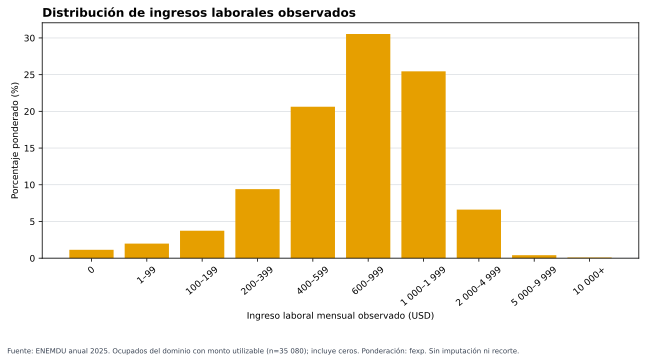

In [6]:
# BLOQUE 6: revisar observación y distribución de ingresos.
estados = pd.read_csv(REPORTES / '06_estado_ingresos_ocupados.csv')  # Lee los estados mutuamente excluyentes.
ingreso = pd.read_csv(REPORTES / '07_resumen_ingresos_observados.csv')  # Lee medidas monetarias.
display(estados[['codigo', 'n', 'porcentaje', 'porcentaje_ponderado']])  # Presenta por qué un monto puede faltar.
display(ingreso)  # Presenta cuantiles y medias.
display(SVG(filename=str(FIGURAS / '05_distribucion_ingresos.svg')))  # Presenta tramos ponderados.

## 6. Observaciones

- Las diferencias entre porcentajes ponderados y sin ponderar muestran por qué debe conservarse `fexp`.
- Ninguna distribución univariada demuestra una asociación ajustada ni un efecto causal.
- Las categorías pequeñas, especialmente algunas de autoidentificación étnica, requerirán revisar tamaños efectivos y estabilidad antes de comparar desempeño.
- La concentración urbana y provincial puede afectar la precisión territorial; se evaluará con el diseño muestral.
- Los ingresos se mantienen fuera de los predictores porque intervienen en la clasificación laboral y producirían fuga de información.

**Siguiente etapa recomendada:** análisis bivariado de empleo adecuado por sexo, área, educación y territorio, primero con estimaciones descriptivas y después con incertidumbre compatible con estratos, UPM y ponderación.

**Para reflexionar:**  por qué el 69,5 % observado en entrenamiento no debe presentarse como la tasa nacional anual y por qué una exactitud de 70 % podría ser poco informativa para un clasificador.